# DQN train evaluation

<div class="alert alert-success">In this notebook, I evaluate the DQN training result.</div> 

In [1]:
import matplotlib.pyplot as plt
import json

In [2]:
with open('training_state.json', 'r') as f:
    training_result = json.load(f)

In [3]:
data = training_result['logs']
len(data)

3454

In [4]:
rewards = [entry['reward'] for entry in data if entry.get("reward") is not None]
accuracies = [entry['accuracy'] for entry in data if entry.get("accuracy") is not None]
training_losses = [entry['train_loss'] for entry in data if entry.get("train_loss") is not None]
precision_recall = [(entry['precision'], entry['recall']) for entry in data]

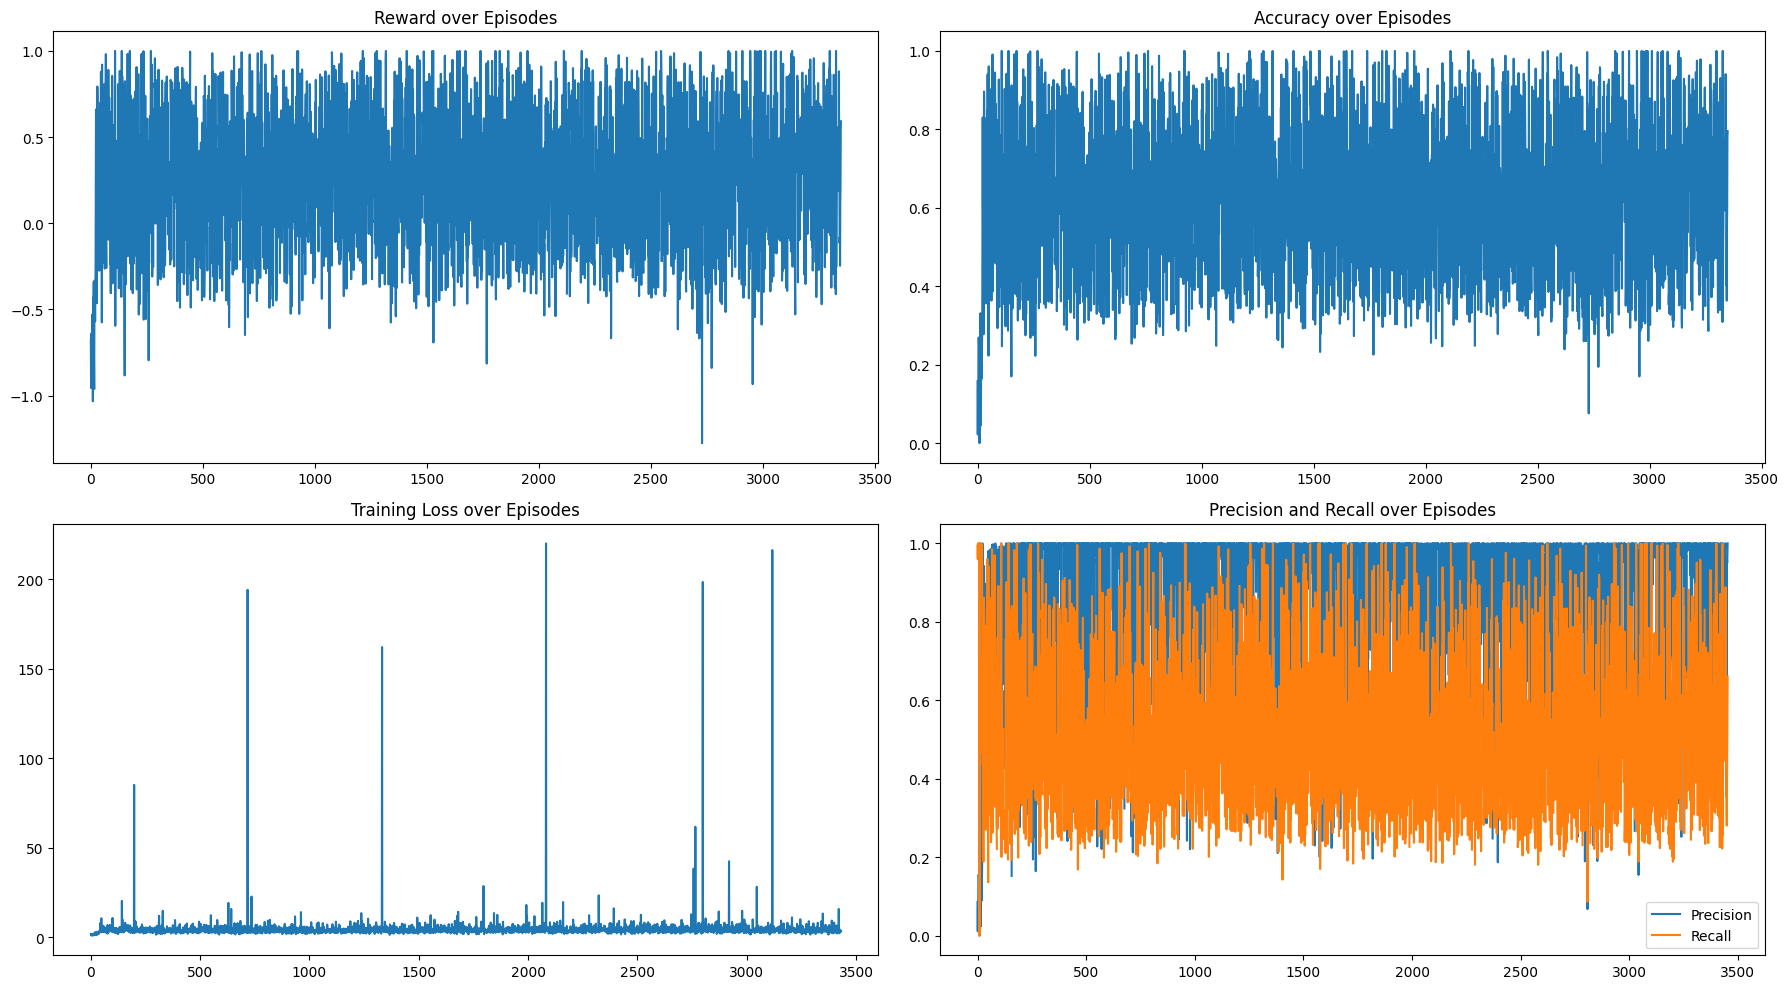

In [5]:
fig, axes = plt.subplots(2,2,figsize=(18, 10))
axes[0,0].plot(rewards, label='Reward')
axes[0,0].set_title('Reward over Episodes')
axes[0,1].plot(accuracies, label='Accuracy')
axes[0,1].set_title('Accuracy over Episodes')
axes[1,0].plot(training_losses, label='Training Loss')
axes[1,0].set_title('Training Loss over Episodes')
axes[1,1].plot([p for p, r in precision_recall], label='Precision')
axes[1,1].plot([r for p, r in precision_recall], label='Recall')
axes[1,1].set_title('Precision and Recall over Episodes')
axes[1,1].legend()
plt.tight_layout()

In [6]:
true_positives = 0.0
false_positives = 0.0
true_negatives = 0.0
false_negatives = 0.0
true_tentatives = 0.0
false_tentatives = 0.0
count = 0
for entry in data:
    count += 1
    info = entry.get("info", {})
    if not isinstance(info, dict):
        continue

    for k, v in info.items():
        if k == "true_positive":
            true_positives += v
        if k == "false_positive":
            false_positives += v
        if k == "true_negative":
            true_negatives += v
        if k == "false_negative":
            false_negatives += v
        if k == "true_tentative":
            true_tentatives += v
        if k == "false_tentative":
            false_tentatives += v

true_positive = true_positives / count
false_positive = false_positives / count
true_negative = true_negatives / count
false_negative = false_negatives / count
true_tentative = true_tentatives / count
false_tentative = false_tentatives / count


In [7]:
print(f"True Positives: {true_positive:.4f}")

True Positives: 16.0785


[Click here for Annotated Heatmap Guide](https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html)

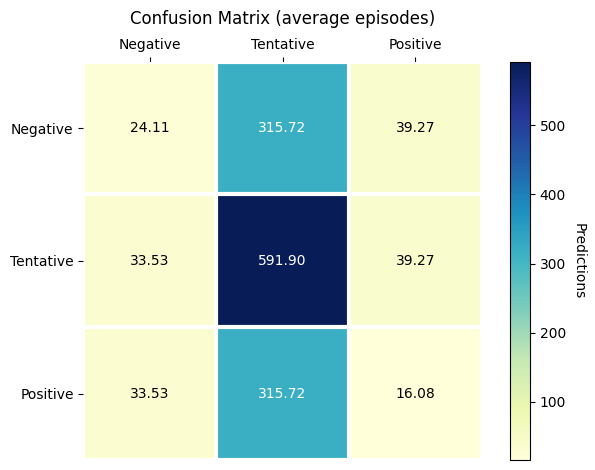

In [11]:
import numpy as np
import matplotlib

truth = ["Negative", "Tentative", "Positive"]
prediction = ["Negative", "Tentative", "Positive"]

truth_table = np.array([[true_negative, false_tentative, false_positive],
                        [false_negative, true_tentative, false_positive],
                        [false_negative, false_tentative, true_positive]])
fig, ax = plt.subplots()
im = ax.imshow(truth_table, cmap="YlGnBu")
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Predictions", rotation=-90, va="bottom")


ax.set_xticks(range(len(prediction)), labels=prediction,
              ha="center", rotation_mode="anchor")
ax.set_yticks(range(len(truth)), labels=truth)
ax.tick_params(top=True, bottom=False,
                labeltop=True, labelbottom=False)
ax.spines[:].set_visible(False)

ax.set_xticks(np.arange(len(prediction)+1)-.5, minor=True)
ax.set_yticks(np.arange(len(truth)+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)
valfmt = matplotlib.ticker.StrMethodFormatter("{x:.2f}")
data = im.get_array()
threshold = im.norm(data.max())/2.
# Set default alignment to center, but allow it to be
    # overwritten by textkw.
kw = dict(horizontalalignment="center",
            verticalalignment="center")
texts = []
textcolors=("black", "white")
for i in range(len(truth)):
    for j in range(len(prediction)):
        # text = ax.text(j, i, truth_table[i, j].round(4),
        #                ha="center", va="center", color="w")
        kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
        text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
        texts.append(text)

ax.set_title("Confusion Matrix (average episodes)", pad=10)
fig.tight_layout()
plt.show()

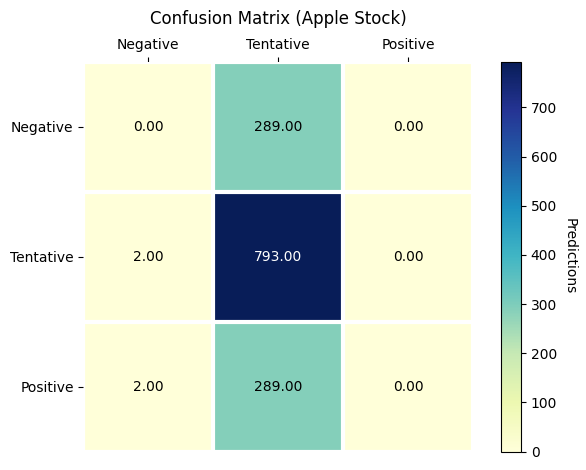

In [9]:
with open('training_state.json', 'r') as f:
    training_result = json.load(f)
    # print(type(training_result))
    # print(training_result['logs'][0])
    for entry in training_result['logs']:
        if entry['ticker'] == 'AAPL.parquet':
            apple_result = entry['info']

truth = ["Negative", "Tentative", "Positive"]
prediction = ["Negative", "Tentative", "Positive"]

truth_table = np.array([[apple_result['true_negative'], apple_result['false_tentative'], apple_result['false_positive']],
                        [apple_result['false_negative'], apple_result['true_tentative'], apple_result['false_positive']],
                        [apple_result['false_negative'], apple_result['false_tentative'], apple_result['true_positive']]])
fig, ax = plt.subplots()
im = ax.imshow(truth_table, cmap="YlGnBu")
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Predictions", rotation=-90, va="bottom")


ax.set_xticks(range(len(prediction)), labels=prediction,
              ha="center", rotation_mode="anchor")
ax.set_yticks(range(len(truth)), labels=truth)
ax.tick_params(top=True, bottom=False,
                labeltop=True, labelbottom=False)
ax.spines[:].set_visible(False)

ax.set_xticks(np.arange(len(prediction)+1)-.5, minor=True)
ax.set_yticks(np.arange(len(truth)+1)-.5, minor=True)
ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
ax.tick_params(which="minor", bottom=False, left=False)
valfmt = matplotlib.ticker.StrMethodFormatter("{x:.2f}")
data = im.get_array()
threshold = im.norm(data.max())/2.
# Set default alignment to center, but allow it to be
    # overwritten by textkw.
kw = dict(horizontalalignment="center",
            verticalalignment="center")
texts = []
textcolors=("black", "white")
for i in range(len(truth)):
    for j in range(len(prediction)):
        # text = ax.text(j, i, truth_table[i, j].round(4),
        #                ha="center", va="center", color="w")
        kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
        text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
        texts.append(text)

ax.set_title("Confusion Matrix (Apple Stock)", pad=10)
fig.tight_layout()
plt.show()

The preceding confusion matrix on average values over all episodes reveal that the model learned to predict "Tentative" state as it was the most common and correct target. 

## Summary
🍋 Evaluated the DQN training result


|Date (YYYY-MM-DD)|Version|Created By|  
|--|--|--|
|2026-03-15|1.0|Battogtokh Baasanjav|